In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix

In [2]:
df = sns.load_dataset("titanic")

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<Axes: xlabel='survived', ylabel='count'>

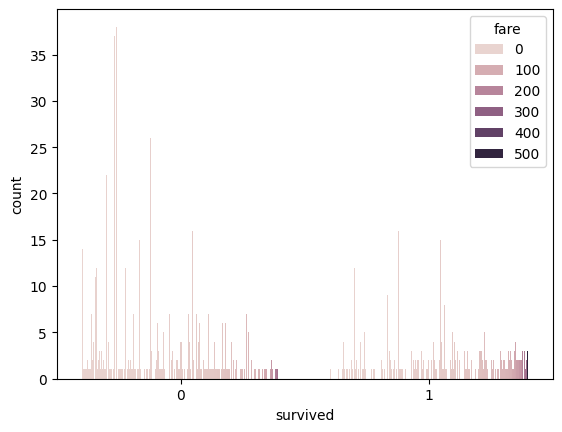

In [4]:
sns.countplot(data=df,x='survived',hue='fare')

In [5]:
df['adult_male'].value_counts()

,count
adult_male,
True,537
False,354


In [6]:
df['sex'].value_counts()

,count
sex,
male,577
female,314


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [8]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [9]:
df = df.drop(['alive','alone','embark_town','deck','who','adult_male'],axis=1)

In [10]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class
0,0,3,male,22.0,1,0,7.2500,S,Third
1,1,1,female,38.0,1,0,71.2833,C,First
2,1,3,female,26.0,0,0,7.9250,S,Third
3,1,1,female,35.0,1,0,53.1000,S,First
4,0,3,male,35.0,0,0,8.0500,S,Third


In [11]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0


In [12]:
X = df.drop('survived',axis=1)
y = df['survived']

In [13]:
num_x = X.select_dtypes(include=['int64','float64']).columns
cat_x = X.select_dtypes(include=['object']).columns

In [14]:
num_enc = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scalar',StandardScaler())
])
cat_enc = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder())
])


In [15]:
from sklearn.compose import ColumnTransformer
preprocesser = ColumnTransformer(transformers=[
    ('num',num_enc,num_x),
    ('cat',cat_enc,cat_x)
])

In [16]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
lr = LogisticRegression()


In [18]:
model = Pipeline([
    ('processor',preprocesser),
    ('model',lr)
])

In [19]:
model.fit(X_train,y_train)

Pipeline(steps=[('processor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scalar',
                                                                   StandardScaler())]),
                                                  Index(['pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder())]),
                                                  Index(['sex', 'embarked'], dtype='object'))])),
                ('model', LogisticRegression())])

In [20]:
y_pred = model.predict(X_test)

In [21]:
acc = accuracy_score(y_test,y_pred)
classification_report = classification_report(y_test,y_pred)
confusion_matrix = confusion_matrix(y_test,y_pred)

print(f"Accuracy: {acc}")
print(f"Classification Report: {classification_report}")
print(f"Confusion Matrix: {confusion_matrix}")

Accuracy: 0.8100558659217877
Classification Report:               precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

Confusion Matrix: [[90 15]
 [19 55]]


In [22]:
from sklearn.model_selection import cross_val_score


In [23]:
clf = cross_val_score(model,X,y,cv=5)

In [24]:
clf

array([0.77653631, 0.78651685, 0.78089888, 0.76966292, 0.8258427 ])

In [25]:
models = {
    'SVC': Pipeline([('preprocessor', preprocesser), ('classifier', SVC(kernel='rbf',C=1.0,gamma='auto'))]),
    'KNeighborsClassifier': Pipeline([('preprocessor', preprocesser), ('classifier', KNeighborsClassifier(n_neighbors=5))]),
    'GaussianNB': Pipeline([('preprocessor', preprocesser), ('classifier', GaussianNB())])
}

for name,model in models.items():
  model.fit(X_train,y_train)
  model.predict(X_test)
  print(f"{name} = {str(model.score(X_test,y_test))}")

SVC = 0.8156424581005587
KNeighborsClassifier = 0.8100558659217877
GaussianNB = 0.776536312849162


In [26]:
from sklearn.model_selection import StratifiedKFold


In [27]:
kfold = StratifiedKFold(n_splits=5, random_state=None, shuffle=False)
cvs = cross_val_score(model,X,y,cv=kfold)
print(cvs)

[0.76536313 0.79775281 0.78651685 0.79213483 0.79775281]


In [28]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
rf = RandomForestClassifier(n_estimators=100,class_weight="balanced",random_state=42)

In [31]:
model_rf = Pipeline([
    ('processor', preprocesser),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42))
])

model_rf.fit(X_train, y_train)

Pipeline(steps=[('processor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scalar',
                                                                   StandardScaler())]),
                                                  Index(['pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder())]),
                                                  Index(['sex', 'embarked'], dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [32]:
pred = model_rf.predict(X_test)

In [35]:
acc = accuracy_score(y_test,pred)
classification_report = classification_report(y_test,pred)
confusion_matrix = confusion_matrix(y_test,pred)

print(f"Accuracy: {acc}")
print(f"Classification Report: {classification_report}")
print(f"Confusion Matrix: {confusion_matrix}")

Accuracy: 0.8212290502793296
Classification Report:               precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

Confusion Matrix: [[91 14]
 [18 56]]


In [36]:
from sklearn.model_selection import GridSearchCV

In [40]:
gv = GridSearchCV(estimator=model_rf,param_grid={'classifier__n_estimators':[100], 'classifier__class_weight':["balanced"], 'classifier__random_state':[42]})

In [41]:
gv.fit(X_train,y_train)

GridSearchCV(estimator=Pipeline(steps=[('processor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scalar',
                                                                                          StandardScaler())]),
                                                                         Index(['pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder())]),
                                                                         Index(['sex', 'embarked'], dtype='object'))])),
                                       ('classifier',
                                        RandomForestClassifier(class_weight='balanced',
                                                               random_state=42))]),
             param_grid={'classifier__class_weight': ['balanced'],
                         'classifier__n_estimators': [100],
                         'classifier__random_state': [42]})

In [42]:
pred = gv.predict(X_test)

In [45]:
acc = accuracy_score(y_test,y_pred)
classification_report = classification_report(y_test,y_pred)
confusion_matrix = confusion_matrix(y_test,y_pred)

print(f"Accuracy: {acc}")
print(f"Classification Report: {classification_report}")
print(f"Confusion Matrix: {confusion_matrix}")

Accuracy: 0.8100558659217877
Classification Report:               precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

Confusion Matrix: [[90 15]
 [19 55]]


In [60]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [61]:
X_train['sex'] = X_train['sex'].map({'male':0,'female':1})
X_test['sex'] = X_test['sex'].map({'male':0,'female':1})

In [62]:
X_train

,pclass,sex,age,sibsp,parch,fare,embarked,class
331,1,NaN,45.5,0,0,28.5000,1.0,1
733,2,NaN,23.0,0,0,13.0000,1.0,2
382,3,NaN,32.0,0,0,7.9250,1.0,3
704,3,NaN,26.0,1,0,7.8542,1.0,3
813,3,NaN,6.0,4,2,31.2750,1.0,3
...,...,...,...,...,...,...,...,...
106,3,NaN,21.0,0,0,7.6500,1.0,3
270,1,NaN,NaN,0,0,31.0000,1.0,1
860,3,NaN,41.0,2,0,14.1083,1.0,3
435,1,NaN,14.0,1,2,120.0000,1.0,1


In [63]:
X_train['embarked'] = X_train['embarked'].map({'S':1,'C':2,'Q':3})
X_test['embarked'] = X_test['embarked'].map({'S':1,'C':2,'Q':3})

In [66]:
gb = HistGradientBoostingClassifier(max_iter=100, learning_rate=1.0,
    max_depth=1, random_state=0).fit(X_train, y_train)

In [68]:
prediction = gb.predict(X_test)

In [71]:
acc = accuracy_score(y_test,prediction)
acc

0.7262569832402235